# 23 — Assembly101 Three-Seed Repetition of CE, Text Alignment, and KD

This notebook tests whether the main single-seed Assembly101 findings
from notebooks 19–21 are reproducible.

It compares three **pre-specified** video-only students:

1. controlled CE-only student;
2. learnable text-prototype student (`beta_text=0.01`);
3. selected KD student (`lambda_KD=0.2`, `T=4`, all stages).

Seed 7 is reused from the completed notebooks. Only seeds 17 and 42
are newly trained, so the full run performs six new training runs.
Hyperparameters are not searched again. Within each new seed, CE and
KD start from the exact same MS-TCN state; the text student receives
the same segmentation backbone plus its deterministic auxiliary head.

The teacher is frozen and used only during KD training. Validation,
test, and deployment always call `student(video)`.


## Fixed replication protocol

| Item | Value |
|---|---|
| Dataset | Assembly101 official train/validation/test split |
| Representation | CLIP ViT-B/16, `512 x 16` |
| Architecture | Four-stage MS-TCN |
| Seeds | `7, 17, 42` |
| Newly trained seeds | `17, 42` |
| CE | supervised segmentation loss only |
| Text | learnable CLIP prototypes, `beta_text=0.01` |
| KD | `lambda_KD=0.2`, `T=4`, all-stage distillation |
| Checkpoint selection | validation `F1@25 + 0.01 x Edit` |
| Test policy | one evaluation of the fixed best-validation checkpoint |
| Inference | video only |

The primary outputs are per-seed results, `mean +/- sample std`, and
paired `KD - CE` / `Text - CE` differences. Three seeds estimate
training variability but are still too few for strong significance
claims.


## 1. Mount Google Drive


In [1]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


## 2. Imports, paths, and fixed configuration


In [2]:
from pathlib import Path
from datetime import datetime, timezone

import gc
import hashlib
import json
import math
import platform
import random
import time
import traceback

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

pd.set_option("display.max_columns", 220)
pd.set_option("display.max_colwidth", 260)

DRIVE_ROOT = Path("/content/drive/MyDrive/mmf_tas_lab_data")
FEATURE_ROOT = (
    DRIVE_ROOT
    / "text_assisted_tas"
    / "assembly101"
    / "coarse_mstcn_format"
    / "streaming_visual_features_v1"
)
DATA_ROOT = FEATURE_ROOT / "clip_vitb16"

NOTEBOOK18_SUMMARY = (
    FEATURE_ROOT / "runs" / "18_text_assisted_concat_teachers"
    / "final_summary_full.json"
)
NOTEBOOK19_SUMMARY = (
    FEATURE_ROOT / "runs" / "19_video_only_kd_students"
    / "full" / "final_summary.json"
)
NOTEBOOK20_SUMMARY = (
    FEATURE_ROOT / "runs" / "20_learnable_text_students"
    / "full" / "final_summary.json"
)
NOTEBOOK21_SUMMARY = (
    FEATURE_ROOT / "runs" / "21_text_student_kd_search"
    / "full" / "final_summary.json"
)

OUT_ROOT = FEATURE_ROOT / "runs" / "23_three_seed_repetition"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

RUN_MODE = "full"
# RUN_MODE = "smoke"

HISTORICAL_SEED = 7
RUN_CONFIGS = {
    "smoke": {
        "epochs": 3,
        "max_train_sequences": 64,
        "max_val_sequences": 32,
        "max_test_sequences": 32,
        "eval_every": 1,
        "patience_evals": None,
        "replication_seeds": [17],
    },
    "full": {
        "epochs": 120,
        "max_train_sequences": None,
        "max_val_sequences": None,
        "max_test_sequences": None,
        "eval_every": 5,
        "patience_evals": 12,
        "replication_seeds": [17, 42],
    },
}
if RUN_MODE not in RUN_CONFIGS:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")
CFG = RUN_CONFIGS[RUN_MODE]

REPLICATION_SEEDS = list(CFG["replication_seeds"])
ALL_SEEDS = [HISTORICAL_SEED] + REPLICATION_SEEDS
CURRENT_SEED = HISTORICAL_SEED
STRATEGIES = ["ce", "text", "kd"]

FIXED_TEXT_MODE = "learnable"
FIXED_TEXT_BETA = 0.01
FIXED_KD_LAMBDA = 0.2
FIXED_KD_TEMPERATURE = 4.0
FIXED_KD_STAGE_POLICY = "all"

EXPECTED_VIDEO_DIM = 512
EXPECTED_TEXT_DIM = 512
EXPECTED_TEMPORAL_LENGTH = 16
EXPECTED_NUM_CLASSES = 202

NUM_STAGES = 4
NUM_LAYERS = 6
NUM_F_MAPS = 64
DROPOUT = 0.5

BATCH_SIZE = 64
NUM_WORKERS = 0
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 5.0

SMOOTHING_WEIGHT = 0.15
SMOOTHING_CLIP_VALUE = 16.0
INITIAL_TEXT_TEMPERATURE = 0.07
LEARNABLE_RESIDUAL_SCALE = 0.10
PROTOTYPE_ANCHOR_WEIGHT = 0.01

RESUME_IF_AVAILABLE = True
FORCE_RETRAIN_COMPLETED = False
FORCE_RECREATE_INITIALIZATIONS = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("RUN_MODE:", RUN_MODE)
print("ALL_SEEDS:", ALL_SEEDS)
print("NEW SEEDS:", REPLICATION_SEEDS)
print("STRATEGIES:", STRATEGIES)
print("OUT_ROOT:", OUT_ROOT)

if RUN_MODE == "full" and not torch.cuda.is_available():
    print("WARNING: full training is running without a GPU.")


Python: 3.12.13
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
RUN_MODE: full
ALL_SEEDS: [7, 17, 42]
NEW SEEDS: [17, 42]
STRATEGIES: ['ce', 'text', 'kd']
OUT_ROOT: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/23_three_seed_repetition


## 3. Resolve and audit notebooks 18–21


In [3]:
for name, path in {
    "CLIP feature dataset": DATA_ROOT,
    "notebook 18 summary": NOTEBOOK18_SUMMARY,
    "notebook 19 summary": NOTEBOOK19_SUMMARY,
    "notebook 20 summary": NOTEBOOK20_SUMMARY,
    "notebook 21 summary": NOTEBOOK21_SUMMARY,
}.items():
    print(f"{name}: {path} -> {path.exists()}")
    if not path.exists():
        raise FileNotFoundError(f"Missing prerequisite: {name}: {path}")

notebook18 = json.loads(NOTEBOOK18_SUMMARY.read_text(encoding="utf-8"))
notebook19 = json.loads(NOTEBOOK19_SUMMARY.read_text(encoding="utf-8"))
notebook20 = json.loads(NOTEBOOK20_SUMMARY.read_text(encoding="utf-8"))
notebook21 = json.loads(NOTEBOOK21_SUMMARY.read_text(encoding="utf-8"))

for number, summary in [
    (18, notebook18), (19, notebook19),
    (20, notebook20), (21, notebook21),
]:
    if summary.get("status") != "completed":
        raise RuntimeError(f"Notebook {number} is not marked completed.")

teacher_key = "mstcn/clip_vitb16"
teacher_experiment = notebook18["experiments"][teacher_key]
TEACHER_CHECKPOINT = Path(
    notebook18["recommended_teacher_for_kd"]["teacher_checkpoint"]
)
TEXT_EMBEDDING_PATH = Path(
    teacher_experiment["input"]["text_embedding_path"]
)
TEXT_METADATA_PATH = Path(
    teacher_experiment["input"]["text_metadata_path"]
)
TRAIN_VIDEO_MEAN_PATH = Path(
    teacher_experiment["paths"]["train_video_mean"]
)
TRAIN_VIDEO_STD_PATH = Path(
    teacher_experiment["paths"]["train_video_std"]
)

selected_text = notebook20["selected_text_strategy"]
selected_kd = notebook21["selected_kd_configuration"]

assert str(selected_text["prototype_mode"]) == FIXED_TEXT_MODE
assert math.isclose(float(selected_text["text_beta"]), FIXED_TEXT_BETA)
assert math.isclose(float(selected_kd["kd_lambda"]), FIXED_KD_LAMBDA)
assert math.isclose(float(selected_kd["temperature"]), FIXED_KD_TEMPERATURE)
assert str(selected_kd["stage_policy"]) == FIXED_KD_STAGE_POLICY

for name, path in {
    "teacher checkpoint": TEACHER_CHECKPOINT,
    "CLIP action-text embeddings": TEXT_EMBEDDING_PATH,
    "CLIP action-text metadata": TEXT_METADATA_PATH,
    "train video mean": TRAIN_VIDEO_MEAN_PATH,
    "train video std": TRAIN_VIDEO_STD_PATH,
}.items():
    print(f"{name}: {path} -> {path.exists()}")
    if not path.exists():
        raise FileNotFoundError(f"Missing artifact: {name}: {path}")

print(json.dumps({
    "fixed_text": {
        "prototype_mode": FIXED_TEXT_MODE,
        "beta": FIXED_TEXT_BETA,
    },
    "fixed_kd": {
        "lambda": FIXED_KD_LAMBDA,
        "temperature": FIXED_KD_TEMPERATURE,
        "stage_policy": FIXED_KD_STAGE_POLICY,
    },
    "hyperparameters_reselected_per_seed": False,
    "teacher_retrained_per_seed": False,
    "test_used_for_configuration_selection": False,
}, indent=2))


CLIP feature dataset: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16 -> True
notebook 18 summary: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/18_text_assisted_concat_teachers/final_summary_full.json -> True
notebook 19 summary: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/19_video_only_kd_students/full/final_summary.json -> True
notebook 20 summary: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/20_learnable_text_students/full/final_summary.json -> True
notebook 21 summary: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/21_text_student_kd_search/full/final_summary.json -> True
teacher checkpoint:

## 4. Reproducibility, mapping, and official split


In [4]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def read_nonempty_lines(path):
    return [
        line.strip()
        for line in Path(path).read_text(
            encoding="utf-8", errors="replace"
        ).splitlines()
        if line.strip()
    ]


def load_mapping(path):
    id_to_label = {}
    label_to_id = {}
    for line in read_nonempty_lines(path):
        class_id_text, label = line.split(maxsplit=1)
        class_id = int(class_id_text)
        if class_id in id_to_label or label in label_to_id:
            raise ValueError(f"Duplicate mapping entry: {line}")
        id_to_label[class_id] = label
        label_to_id[label] = class_id
    return id_to_label, label_to_id


def resolve_bundle(split_dir, split_name):
    split_dir = Path(split_dir)
    for candidate in [
        split_dir / f"{split_name}.bundle",
        split_dir / f"{split_name}.split1.bundle",
    ]:
        if candidate.exists():
            return candidate
    candidates = sorted(
        path
        for path in split_dir.glob("*.bundle")
        if split_name.lower() in path.name.lower()
        and ".partial." not in path.name.lower()
        and not path.name.lower().endswith(".partial.bundle")
    )
    if len(candidates) != 1:
        raise FileNotFoundError(
            f"Could not uniquely resolve {split_name}: {candidates}"
        )
    return candidates[0]


def read_bundle(path):
    sequence_ids = [Path(line).stem for line in read_nonempty_lines(path)]
    if len(sequence_ids) != len(set(sequence_ids)):
        raise ValueError(f"Duplicate IDs in {path}")
    return sequence_ids


def limit_ids(sequence_ids, maximum):
    if maximum is None:
        return list(sequence_ids)
    return list(sequence_ids)[: int(maximum)]


set_seed(CURRENT_SEED)
MAPPING_PATH = DATA_ROOT / "mapping.txt"
SPLIT_DIR = DATA_ROOT / "splits"
id_to_label, label_to_id = load_mapping(MAPPING_PATH)
num_classes = len(id_to_label)

if num_classes != EXPECTED_NUM_CLASSES:
    raise ValueError(
        f"Expected {EXPECTED_NUM_CLASSES} classes, found {num_classes}"
    )
if set(id_to_label) != set(range(num_classes)):
    raise ValueError("Class IDs must be contiguous from 0 to 201.")

train_ids_full = read_bundle(resolve_bundle(SPLIT_DIR, "train"))
val_ids_full = read_bundle(resolve_bundle(SPLIT_DIR, "val"))
test_ids_full = read_bundle(resolve_bundle(SPLIT_DIR, "test"))

assert set(train_ids_full).isdisjoint(set(val_ids_full))
assert set(train_ids_full).isdisjoint(set(test_ids_full))
assert set(val_ids_full).isdisjoint(set(test_ids_full))
assert len(set(train_ids_full) | set(val_ids_full) | set(test_ids_full)) == 680

train_ids = limit_ids(train_ids_full, CFG["max_train_sequences"])
val_ids = limit_ids(val_ids_full, CFG["max_val_sequences"])
test_ids = limit_ids(test_ids_full, CFG["max_test_sequences"])

print("Classes:", num_classes)
print("Train:", len(train_ids))
print("Validation:", len(val_ids))
print("Test reserved:", len(test_ids))


Classes: 202
Train: 393
Validation: 120
Test reserved: 167


## 5. Text bank, normalization, dataset, and loaders


In [5]:
text_embeddings = np.load(TEXT_EMBEDDING_PATH).astype(np.float32)
text_metadata = pd.read_csv(TEXT_METADATA_PATH)
required_columns = {"model_class_id", "action_cls", "prompt", "clip_model"}
missing_columns = required_columns - set(text_metadata.columns)
if missing_columns:
    raise KeyError(f"Missing text metadata columns: {sorted(missing_columns)}")

if text_embeddings.shape != (EXPECTED_NUM_CLASSES, EXPECTED_TEXT_DIM):
    raise ValueError(f"Unexpected text shape: {text_embeddings.shape}")

text_metadata = text_metadata.sort_values("model_class_id").reset_index(drop=True)
if not np.array_equal(
    text_metadata["model_class_id"].to_numpy(),
    np.arange(EXPECTED_NUM_CLASSES),
):
    raise ValueError("Text metadata does not cover IDs 0..201 exactly.")

for class_id in range(num_classes):
    action_name = str(text_metadata.loc[class_id, "action_cls"])
    if action_name != str(id_to_label[class_id]):
        raise ValueError(
            f"Text/mapping mismatch at {class_id}: "
            f"{action_name} != {id_to_label[class_id]}"
        )

text_embeddings /= np.maximum(
    np.linalg.norm(text_embeddings, axis=1, keepdims=True), 1e-12
)
text_embeddings = text_embeddings.astype(np.float32)
text_bank_tensor = torch.from_numpy(text_embeddings)

train_video_mean = np.load(TRAIN_VIDEO_MEAN_PATH).astype(np.float32)
train_video_std = np.load(TRAIN_VIDEO_STD_PATH).astype(np.float32)
if train_video_mean.shape != (EXPECTED_VIDEO_DIM,):
    raise ValueError(f"Unexpected mean shape: {train_video_mean.shape}")
if train_video_std.shape != (EXPECTED_VIDEO_DIM,):
    raise ValueError(f"Unexpected std shape: {train_video_std.shape}")
if np.any(train_video_std <= 0):
    raise ValueError("All train standard deviations must be positive.")


class Assembly101KDDataset(Dataset):
    def __init__(self, sequence_ids):
        self.sequence_ids = list(sequence_ids)
        self.feature_dir = DATA_ROOT / "features"
        self.gt_dir = DATA_ROOT / "groundTruth"

    def __len__(self):
        return len(self.sequence_ids)

    def __getitem__(self, index):
        sequence_id = self.sequence_ids[index]
        video = np.load(
            self.feature_dir / f"{sequence_id}.npy"
        ).astype(np.float32)
        label_names = read_nonempty_lines(
            self.gt_dir / f"{sequence_id}.txt"
        )
        labels = np.asarray(
            [label_to_id[label] for label in label_names], dtype=np.int64
        )

        if video.shape != (EXPECTED_VIDEO_DIM, EXPECTED_TEMPORAL_LENGTH):
            raise ValueError(
                f"Unexpected video shape for {sequence_id}: {video.shape}"
            )
        if labels.shape != (EXPECTED_TEMPORAL_LENGTH,):
            raise ValueError(
                f"Unexpected labels for {sequence_id}: {labels.shape}"
            )
        if not np.isfinite(video).all():
            raise ValueError(f"Non-finite video values for {sequence_id}")

        video = (
            video - train_video_mean[:, None]
        ) / (
            train_video_std[:, None] + 1e-8
        )
        privileged_text = text_embeddings[labels].T.astype(np.float32)

        return {
            "sequence_id": sequence_id,
            "video": torch.from_numpy(video),
            "privileged_text": torch.from_numpy(privileged_text),
            "labels": torch.from_numpy(labels),
        }


train_dataset = Assembly101KDDataset(train_ids)
val_dataset = Assembly101KDDataset(val_ids)
test_dataset = Assembly101KDDataset(test_ids)


def make_train_loader(epoch):
    generator = torch.Generator()
    generator.manual_seed(CURRENT_SEED + int(epoch))
    return DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        generator=generator,
    )


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

sample = next(iter(make_train_loader(1)))
assert sample["video"].shape[1:] == (
    EXPECTED_VIDEO_DIM, EXPECTED_TEMPORAL_LENGTH
)
assert sample["privileged_text"].shape[1:] == (
    EXPECTED_TEXT_DIM, EXPECTED_TEMPORAL_LENGTH
)
assert sample["labels"].shape[1:] == (EXPECTED_TEMPORAL_LENGTH,)

print("Text bank:", tuple(text_bank_tensor.shape))
print("Train/val/test:", len(train_dataset), len(val_dataset), len(test_dataset))
print("Video batch:", tuple(sample["video"].shape))
print("Privileged text batch:", tuple(sample["privileged_text"].shape))


Text bank: (202, 512)
Train/val/test: 393 120 167
Video batch: (64, 512, 16)
Privileged text batch: (64, 512, 16)


## 6. Temporal action segmentation metrics


In [6]:
IGNORE_CLASS_NAMES = {"background", "SIL", "silence"}
ignore_class_ids = {
    label_to_id[name]
    for name in IGNORE_CLASS_NAMES
    if name in label_to_id
}


def collapse_segments(frame_labels, ignored_ids=None):
    ignored_ids = set(ignored_ids or [])
    labels, starts, ends = [], [], []
    active = None
    for index, label in enumerate(frame_labels):
        label = int(label)
        if label in ignored_ids:
            if active is not None:
                ends.append(index)
                active = None
            continue
        if label != active:
            if active is not None:
                ends.append(index)
            labels.append(label)
            starts.append(index)
            active = label
    if active is not None:
        ends.append(len(frame_labels))
    return labels, starts, ends


def levenshtein_distance(predicted, target):
    distance = np.zeros(
        (len(predicted) + 1, len(target) + 1), dtype=np.int32
    )
    distance[:, 0] = np.arange(len(predicted) + 1)
    distance[0, :] = np.arange(len(target) + 1)
    for row in range(1, len(predicted) + 1):
        for column in range(1, len(target) + 1):
            substitution = int(predicted[row - 1] != target[column - 1])
            distance[row, column] = min(
                distance[row - 1, column] + 1,
                distance[row, column - 1] + 1,
                distance[row - 1, column - 1] + substitution,
            )
    return int(distance[-1, -1])


def edit_score_single(prediction, target, ignored_ids=None):
    predicted_segments, _, _ = collapse_segments(prediction, ignored_ids)
    target_segments, _, _ = collapse_segments(target, ignored_ids)
    if not predicted_segments and not target_segments:
        return 100.0
    denominator = max(len(predicted_segments), len(target_segments))
    if denominator == 0:
        return 0.0
    distance = levenshtein_distance(predicted_segments, target_segments)
    return (1.0 - distance / denominator) * 100.0


def f_score_single(prediction, target, overlap, ignored_ids=None):
    predicted_labels, predicted_starts, predicted_ends = collapse_segments(
        prediction, ignored_ids
    )
    target_labels, target_starts, target_ends = collapse_segments(
        target, ignored_ids
    )
    true_positives = 0
    false_positives = 0
    hits = np.zeros(len(target_labels), dtype=np.float32)

    for predicted_index in range(len(predicted_labels)):
        best_iou = 0.0
        best_target = -1
        for target_index in range(len(target_labels)):
            if predicted_labels[predicted_index] != target_labels[target_index]:
                continue
            intersection = (
                min(predicted_ends[predicted_index], target_ends[target_index])
                - max(predicted_starts[predicted_index], target_starts[target_index])
            )
            union = (
                max(predicted_ends[predicted_index], target_ends[target_index])
                - min(predicted_starts[predicted_index], target_starts[target_index])
            )
            iou = max(intersection, 0) / union if union > 0 else 0.0
            if iou > best_iou:
                best_iou = iou
                best_target = target_index
        if best_iou >= overlap and best_target >= 0 and hits[best_target] == 0:
            true_positives += 1
            hits[best_target] = 1
        else:
            false_positives += 1

    false_negatives = len(target_labels) - int(hits.sum())
    return true_positives, false_positives, false_negatives


def compute_metrics(predictions, targets, ignored_ids=None):
    total_correct = 0
    total_positions = 0
    edit_scores = []
    f_statistics = {
        0.10: [0, 0, 0],
        0.25: [0, 0, 0],
        0.50: [0, 0, 0],
    }
    for sequence_id, prediction in predictions.items():
        target = targets[sequence_id]
        total_correct += int((prediction == target).sum())
        total_positions += len(target)
        edit_scores.append(edit_score_single(prediction, target, ignored_ids))
        for overlap in f_statistics:
            tp, fp, fn = f_score_single(
                prediction, target, overlap, ignored_ids
            )
            f_statistics[overlap][0] += tp
            f_statistics[overlap][1] += fp
            f_statistics[overlap][2] += fn

    metrics = {
        "acc": 100.0 * total_correct / max(total_positions, 1),
        "edit": float(np.mean(edit_scores)) if edit_scores else 0.0,
    }
    for overlap, (tp, fp, fn) in f_statistics.items():
        precision = tp / max(tp + fp, 1e-8)
        recall = tp / max(tp + fn, 1e-8)
        f1 = 2.0 * precision * recall / max(precision + recall, 1e-8)
        metrics[f"f1@{int(overlap * 100)}"] = 100.0 * f1
    return metrics


def round_metrics(metrics):
    return {key: round(float(value), 2) for key, value in metrics.items()}


def selection_score(metrics):
    return float(metrics["f1@25"]) + 0.01 * float(metrics["edit"])


print("Ignored class IDs:", ignore_class_ids)
print("Metrics ready.")


Ignored class IDs: set()
Metrics ready.


## 7. Exact teacher and student architectures


In [7]:
class DilatedResidualLayer(nn.Module):
    def __init__(self, dilation, channels, dropout):
        super().__init__()
        self.conv_dilated = nn.Conv1d(
            channels,
            channels,
            kernel_size=3,
            padding=dilation,
            dilation=dilation,
        )
        self.conv_1x1 = nn.Conv1d(channels, channels, kernel_size=1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, inputs):
        output = F.relu(self.conv_dilated(inputs))
        output = self.conv_1x1(output)
        output = self.dropout(output)
        return inputs + output


class SingleStage(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.input_projection = nn.Conv1d(
            input_dim, NUM_F_MAPS, kernel_size=1
        )
        self.layers = nn.ModuleList(
            [
                DilatedResidualLayer(
                    dilation=2 ** layer_index,
                    channels=NUM_F_MAPS,
                    dropout=DROPOUT,
                )
                for layer_index in range(NUM_LAYERS)
            ]
        )
        self.output_projection = nn.Conv1d(
            NUM_F_MAPS, num_classes, kernel_size=1
        )

    def forward(self, inputs, return_hidden=False):
        hidden = self.input_projection(inputs)
        for layer in self.layers:
            hidden = layer(hidden)
        logits = self.output_projection(hidden)
        if return_hidden:
            return logits, hidden
        return logits


class MSTCNTeacher(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.stage1 = SingleStage(
            EXPECTED_VIDEO_DIM + EXPECTED_TEXT_DIM, num_classes
        )
        self.refinement_stages = nn.ModuleList(
            [
                SingleStage(num_classes, num_classes)
                for _ in range(NUM_STAGES - 1)
            ]
        )

    def forward(self, video, privileged_text):
        logits = self.stage1(torch.cat([video, privileged_text], dim=1))
        outputs = [logits]
        for stage in self.refinement_stages:
            logits = stage(F.softmax(logits, dim=1))
            outputs.append(logits)
        return torch.stack(outputs, dim=0)


class MSTCNVideoStudent(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.stage1 = SingleStage(EXPECTED_VIDEO_DIM, num_classes)
        self.refinement_stages = nn.ModuleList(
            [
                SingleStage(num_classes, num_classes)
                for _ in range(NUM_STAGES - 1)
            ]
        )

    def forward(self, video):
        logits = self.stage1(video)
        outputs = [logits]
        for stage in self.refinement_stages:
            logits = stage(F.softmax(logits, dim=1))
            outputs.append(logits)
        return torch.stack(outputs, dim=0)


class MSTCNTextEmbeddingStudent(nn.Module):
    def __init__(self, num_classes, clip_text_bank, prototype_mode):
        super().__init__()
        if prototype_mode not in {"fixed", "learnable"}:
            raise ValueError(f"Unknown prototype mode: {prototype_mode}")
        self.prototype_mode = prototype_mode
        self.stage1 = SingleStage(EXPECTED_VIDEO_DIM, num_classes)
        self.refinement_stages = nn.ModuleList(
            [
                SingleStage(num_classes, num_classes)
                for _ in range(NUM_STAGES - 1)
            ]
        )
        self.video_to_text = nn.Conv1d(
            NUM_F_MAPS, EXPECTED_TEXT_DIM, kernel_size=1
        )
        self.register_buffer(
            "clip_text_bank",
            F.normalize(clip_text_bank.float().clone(), dim=-1),
        )
        self.prototype_delta = nn.Parameter(
            torch.zeros_like(self.clip_text_bank),
            requires_grad=(prototype_mode == "learnable"),
        )
        self.logit_scale = nn.Parameter(
            torch.tensor(math.log(1.0 / INITIAL_TEXT_TEMPERATURE))
        )

    def adapted_prototypes(self):
        prototypes = (
            self.clip_text_bank
            + LEARNABLE_RESIDUAL_SCALE * self.prototype_delta
        )
        return F.normalize(prototypes, dim=-1)

    def forward(self, video, return_text_aux=False):
        logits, hidden = self.stage1(video, return_hidden=True)
        outputs = [logits]
        for stage in self.refinement_stages:
            logits = stage(F.softmax(logits, dim=1))
            outputs.append(logits)
        stacked_outputs = torch.stack(outputs, dim=0)
        if not return_text_aux:
            return stacked_outputs
        auxiliary = {
            "projected_video": F.normalize(
                self.video_to_text(hidden), dim=1
            ),
            "prototypes": self.adapted_prototypes(),
            "logit_scale": self.logit_scale.exp().clamp(max=100.0),
        }
        return stacked_outputs, auxiliary


def create_teacher():
    return MSTCNTeacher(num_classes).to(DEVICE)


def create_video_student():
    return MSTCNVideoStudent(num_classes).to(DEVICE)


def create_text_student(prototype_mode):
    return MSTCNTextEmbeddingStudent(
        num_classes=num_classes,
        clip_text_bank=text_bank_tensor,
        prototype_mode=prototype_mode,
    ).to(DEVICE)


with torch.no_grad():
    dummy_video = torch.zeros(
        2, EXPECTED_VIDEO_DIM, EXPECTED_TEMPORAL_LENGTH, device=DEVICE
    )
    dummy_text = torch.zeros(
        2, EXPECTED_TEXT_DIM, EXPECTED_TEMPORAL_LENGTH, device=DEVICE
    )
    teacher_shape = create_teacher()(dummy_video, dummy_text).shape
    video_shape = create_video_student()(dummy_video).shape
    text_model = create_text_student(FIXED_TEXT_MODE)
    text_shape, auxiliary = text_model(
        dummy_video, return_text_aux=True
    )

expected_shape = (
    NUM_STAGES, 2, num_classes, EXPECTED_TEMPORAL_LENGTH
)
assert teacher_shape == expected_shape
assert video_shape == expected_shape
assert text_shape.shape == expected_shape
assert auxiliary["prototypes"].shape == (
    num_classes, EXPECTED_TEXT_DIM
)

print("Teacher output:", tuple(teacher_shape))
print("Video student output:", tuple(video_shape))
print("Text student output:", tuple(text_shape.shape))
print("Final inference signatures: student(video)")

del dummy_video, dummy_text, text_model, text_shape, auxiliary
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Teacher output: (4, 2, 202, 16)
Video student output: (4, 2, 202, 16)
Text student output: (4, 2, 202, 16)
Final inference signatures: student(video)


## 8. Load and freeze the privileged teacher


In [8]:
def load_checkpoint(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


teacher_checkpoint = load_checkpoint(TEACHER_CHECKPOINT)
teacher = create_teacher()
teacher.load_state_dict(
    teacher_checkpoint["model_state_dict"], strict=True
)
teacher.eval()
for parameter in teacher.parameters():
    parameter.requires_grad_(False)

with torch.no_grad():
    teacher_test_output = teacher(
        sample["video"][:2].to(DEVICE),
        sample["privileged_text"][:2].to(DEVICE),
    )
assert teacher_test_output.shape == (
    NUM_STAGES, 2, num_classes, EXPECTED_TEMPORAL_LENGTH
)

print("Teacher checkpoint epoch:", teacher_checkpoint.get("epoch"))
print("Teacher output:", tuple(teacher_test_output.shape))
print(
    "Teacher trainable parameters:",
    sum(parameter.numel() for parameter in teacher.parameters() if parameter.requires_grad),
)
del teacher_test_output


Teacher checkpoint epoch: 120
Teacher output: (4, 2, 202, 16)
Teacher trainable parameters: 0


## 9. Fixed CE, text-alignment, and KD losses


In [9]:
def supervised_loss(outputs, targets):
    total = torch.zeros((), device=outputs.device)
    ce_sum = 0.0
    smooth_sum = 0.0
    for stage_index in range(outputs.shape[0]):
        logits = outputs[stage_index]
        ce = F.cross_entropy(
            logits.permute(0, 2, 1).reshape(-1, logits.shape[1]),
            targets.reshape(-1),
        )
        log_probabilities = F.log_softmax(logits, dim=1)
        smooth = F.mse_loss(
            log_probabilities[:, :, 1:],
            log_probabilities.detach()[:, :, :-1],
            reduction="none",
        )
        smooth = torch.clamp(
            smooth, min=0.0, max=SMOOTHING_CLIP_VALUE
        ).mean()
        total = total + ce + SMOOTHING_WEIGHT * smooth
        ce_sum += float(ce.detach().cpu())
        smooth_sum += float(smooth.detach().cpu())
    return total, {
        "segmentation": float(total.detach().cpu()),
        "cross_entropy_sum": ce_sum,
        "smoothing_sum": smooth_sum,
    }


def distillation_loss(
    student_outputs,
    teacher_outputs,
    temperature,
    stage_policy,
):
    if student_outputs.shape != teacher_outputs.shape:
        raise ValueError(
            f"Student/teacher mismatch: {student_outputs.shape} "
            f"vs {teacher_outputs.shape}"
        )
    if stage_policy == "all":
        stage_indices = range(student_outputs.shape[0])
    elif stage_policy == "final":
        stage_indices = [student_outputs.shape[0] - 1]
    else:
        raise ValueError(f"Unknown stage policy: {stage_policy}")

    losses = []
    for stage_index in stage_indices:
        student_logits = (
            student_outputs[stage_index]
            .permute(0, 2, 1)
            .reshape(-1, student_outputs.shape[2])
        )
        teacher_logits = (
            teacher_outputs[stage_index]
            .detach()
            .permute(0, 2, 1)
            .reshape(-1, teacher_outputs.shape[2])
        )
        student_log_probability = F.log_softmax(
            student_logits / float(temperature), dim=-1
        )
        teacher_probability = F.softmax(
            teacher_logits / float(temperature), dim=-1
        )
        losses.append(
            F.kl_div(
                student_log_probability,
                teacher_probability,
                reduction="batchmean",
            )
            * (float(temperature) ** 2)
        )
    return torch.stack(losses).mean()


def text_alignment_loss(auxiliary, targets):
    similarity_logits = auxiliary["logit_scale"] * torch.einsum(
        "bdt,cd->bct",
        auxiliary["projected_video"],
        auxiliary["prototypes"],
    )
    return F.cross_entropy(
        similarity_logits.permute(0, 2, 1).reshape(-1, num_classes),
        targets.reshape(-1),
    )


def prototype_anchor_loss(model):
    if model.prototype_mode != "learnable":
        return torch.zeros((), device=DEVICE)
    adapted = model.adapted_prototypes()
    return (
        1.0 - (adapted * model.clip_text_bank).sum(dim=-1)
    ).mean()


def kd_total_loss(
    outputs,
    targets,
    teacher_outputs,
    kd_lambda,
    temperature,
    stage_policy,
):
    segmentation, parts = supervised_loss(outputs, targets)
    kd = distillation_loss(
        outputs, teacher_outputs, temperature, stage_policy
    )
    total = segmentation + float(kd_lambda) * kd
    return total, {
        **parts,
        "kd_unweighted": float(kd.detach().cpu()),
        "kd_weighted": float((float(kd_lambda) * kd).detach().cpu()),
        "total": float(total.detach().cpu()),
    }


def combined_total_loss(
    model,
    outputs,
    auxiliary,
    targets,
    teacher_outputs,
    kd_lambda,
    temperature,
    stage_policy,
    text_beta,
):
    segmentation, parts = supervised_loss(outputs, targets)
    kd = distillation_loss(
        outputs, teacher_outputs, temperature, stage_policy
    )
    text = text_alignment_loss(auxiliary, targets)
    anchor = prototype_anchor_loss(model)
    total = (
        segmentation
        + float(kd_lambda) * kd
        + float(text_beta) * text
        + PROTOTYPE_ANCHOR_WEIGHT * anchor
    )
    return total, {
        **parts,
        "kd_unweighted": float(kd.detach().cpu()),
        "kd_weighted": float((float(kd_lambda) * kd).detach().cpu()),
        "text_unweighted": float(text.detach().cpu()),
        "text_weighted": float((float(text_beta) * text).detach().cpu()),
        "prototype_anchor": float(anchor.detach().cpu()),
        "total": float(total.detach().cpu()),
    }


print("KD: L_seg + lambda_KD * L_KD")
print(
    "Combined: L_seg + lambda_KD * L_KD + "
    "beta_text * L_text + gamma_anchor * L_anchor"
)


KD: L_seg + lambda_KD * L_KD
Combined: L_seg + lambda_KD * L_KD + beta_text * L_text + gamma_anchor * L_anchor


In [10]:
def text_total_loss(model, outputs, auxiliary, targets):
    segmentation, parts = supervised_loss(outputs, targets)
    text = text_alignment_loss(auxiliary, targets)
    anchor = prototype_anchor_loss(model)
    total = (
        segmentation
        + FIXED_TEXT_BETA * text
        + PROTOTYPE_ANCHOR_WEIGHT * anchor
    )
    return total, {
        **parts,
        "text_unweighted": float(text.detach().cpu()),
        "text_weighted": float((FIXED_TEXT_BETA * text).detach().cpu()),
        "prototype_anchor": float(anchor.detach().cpu()),
        "total": float(total.detach().cpu()),
    }


def ce_total_loss(outputs, targets):
    total, parts = supervised_loss(outputs, targets)
    return total, {**parts, "total": float(total.detach().cpu())}


print("CE: L_seg")
print("Text: L_seg + 0.01 * L_text + 0.01 * L_anchor")
print("KD: L_seg + 0.2 * L_KD, T=4, all stages")


CE: L_seg
Text: L_seg + 0.01 * L_text + 0.01 * L_anchor
KD: L_seg + 0.2 * L_KD, T=4, all stages


## 10. Seed-specific paired initializations and video-only evaluation


In [11]:
def fingerprint(state_dict):
    digest = hashlib.sha256()
    for key in sorted(state_dict):
        tensor = state_dict[key].detach().cpu().contiguous()
        digest.update(key.encode("utf-8"))
        digest.update(tensor.numpy().tobytes())
    return digest.hexdigest()


def cpu_state_dict(model):
    return {
        key: value.detach().cpu().clone()
        for key, value in model.state_dict().items()
    }


def initialization_config(seed):
    return {
        "seed": int(seed),
        "num_stages": NUM_STAGES,
        "num_layers": NUM_LAYERS,
        "num_f_maps": NUM_F_MAPS,
        "dropout": DROPOUT,
        "video_dim": EXPECTED_VIDEO_DIM,
        "text_dim": EXPECTED_TEXT_DIM,
        "num_classes": num_classes,
        "text_mode": FIXED_TEXT_MODE,
        "text_residual_scale": LEARNABLE_RESIDUAL_SCALE,
    }


def prepare_seed_initializations(seed):
    seed = int(seed)
    seed_root = OUT_ROOT / RUN_MODE / f"seed_{seed}"
    seed_root.mkdir(parents=True, exist_ok=True)
    video_path = seed_root / "shared_video_initialization.pt"
    text_path = seed_root / "shared_text_initialization.pt"
    config = initialization_config(seed)

    if (
        video_path.exists()
        and text_path.exists()
        and not FORCE_RECREATE_INITIALIZATIONS
    ):
        video_payload = load_checkpoint(video_path)
        text_payload = load_checkpoint(text_path)
        if video_payload.get("config") != config:
            raise ValueError(f"Incompatible video initialization: {video_path}")
        if text_payload.get("config") != config:
            raise ValueError(f"Incompatible text initialization: {text_path}")
    else:
        set_seed(seed)
        video_model = create_video_student()
        video_state = cpu_state_dict(video_model)

        set_seed(seed)
        text_model = create_text_student(FIXED_TEXT_MODE)
        incompatible = text_model.load_state_dict(video_state, strict=False)
        expected_missing = {
            "clip_text_bank",
            "prototype_delta",
            "logit_scale",
            "video_to_text.weight",
            "video_to_text.bias",
        }
        if set(incompatible.missing_keys) != expected_missing:
            raise RuntimeError(
                f"Unexpected missing text keys: {incompatible.missing_keys}"
            )
        if incompatible.unexpected_keys:
            raise RuntimeError(
                f"Unexpected video keys: {incompatible.unexpected_keys}"
            )
        text_state = cpu_state_dict(text_model)

        for key, value in video_state.items():
            if key not in text_state or not torch.equal(value, text_state[key]):
                raise RuntimeError(f"Backbone mismatch at key: {key}")

        video_payload = {
            "config": config,
            "model_state_dict": video_state,
            "fingerprint": fingerprint(video_state),
        }
        text_payload = {
            "config": config,
            "model_state_dict": text_state,
            "fingerprint": fingerprint(text_state),
            "backbone_fingerprint": fingerprint(video_state),
        }
        torch.save(video_payload, video_path)
        torch.save(text_payload, text_path)
        del video_model, text_model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return {
        "video_path": str(video_path),
        "text_path": str(text_path),
        "video_state": video_payload["model_state_dict"],
        "text_state": text_payload["model_state_dict"],
        "video_fingerprint": fingerprint(video_payload["model_state_dict"]),
        "text_fingerprint": fingerprint(text_payload["model_state_dict"]),
    }


def create_initialized_student(strategy, initialization):
    if strategy in {"ce", "kd"}:
        model = create_video_student()
        state = initialization["video_state"]
        expected_fingerprint = initialization["video_fingerprint"]
    elif strategy == "text":
        model = create_text_student(FIXED_TEXT_MODE)
        state = initialization["text_state"]
        expected_fingerprint = initialization["text_fingerprint"]
    else:
        raise ValueError(f"Unknown strategy: {strategy}")
    model.load_state_dict(state, strict=True)
    if fingerprint(cpu_state_dict(model)) != expected_fingerprint:
        raise RuntimeError(f"Initialization failed for {strategy}")
    return model, expected_fingerprint


@torch.no_grad()
def evaluate_student(model, loader, save_predictions=False, prediction_dir=None):
    model.eval()
    predictions = {}
    targets = {}
    if save_predictions:
        prediction_dir = Path(prediction_dir)
        prediction_dir.mkdir(parents=True, exist_ok=True)

    for batch in loader:
        video = batch["video"].to(DEVICE, non_blocking=True)
        labels = batch["labels"].cpu().numpy()
        sequence_ids = list(batch["sequence_id"])

        # Strict inference contract: only video is provided.
        outputs = model(video)
        predicted = outputs[-1].argmax(dim=1).detach().cpu().numpy()

        for index, sequence_id in enumerate(sequence_ids):
            pred_ids = predicted[index].astype(np.int64)
            target_ids = labels[index].astype(np.int64)
            predictions[sequence_id] = pred_ids
            targets[sequence_id] = target_ids
            if save_predictions:
                pred_labels = [id_to_label[int(value)] for value in pred_ids]
                (prediction_dir / f"{sequence_id}.txt").write_text(
                    "\n".join(pred_labels) + "\n", encoding="utf-8"
                )

    return (
        compute_metrics(predictions, targets, ignore_class_ids),
        predictions,
        targets,
    )


smoke_initialization = prepare_seed_initializations(REPLICATION_SEEDS[0])
print("Video initialization fingerprint:", smoke_initialization["video_fingerprint"])
print("Text initialization fingerprint:", smoke_initialization["text_fingerprint"])
print("Validation/test inference: student(video)")
del smoke_initialization


Video initialization fingerprint: 23864aae97a12b2d8b010ee3ec41e9b5c9b55e8dc3e4974fe65ba87323652d1f
Text initialization fingerprint: 7ddcc08f4532752c1c84a6aaabf4c9fd942f3700ea73637321d0ef2de29504d3
Validation/test inference: student(video)


## 11. Reuse the completed seed-7 results


In [12]:
def extract_test_metrics(test_block):
    if "metrics" in test_block:
        return dict(test_block["metrics"])
    return dict(test_block)


def historical_record(strategy, validation, test_block, best_epoch, source):
    validation = round_metrics(validation)
    test_metrics = round_metrics(extract_test_metrics(test_block))
    return {
        "seed": HISTORICAL_SEED,
        "strategy": strategy,
        "source": source,
        "best_epoch": int(best_epoch),
        "validation_score": selection_score(validation),
        **{f"val_{key}": value for key, value in validation.items()},
        **{f"test_{key}": value for key, value in test_metrics.items()},
    }


ce7 = notebook19["controlled_ce"]
text7 = notebook20["selected_text_strategy"]
kd7 = notebook21["selected_kd_configuration"]

historical_rows = [
    historical_record(
        "ce",
        ce7["validation"],
        ce7["test"],
        ce7["test"]["best_epoch"],
        "notebook19",
    ),
    historical_record(
        "text",
        text7["validation_metrics"],
        text7["test"],
        text7["test"]["best_epoch"],
        "notebook20",
    ),
    historical_record(
        "kd",
        kd7["best_validation_metrics"],
        notebook21["selected_kd_test"],
        notebook21["selected_kd_test"]["best_epoch"],
        "notebook21",
    ),
]

historical_df = pd.DataFrame(historical_rows)
display(historical_df)
print("Seed 7 is reused; it will not be retrained.")


,seed,strategy,source,best_epoch,validation_score,val_acc,val_edit,val_f1@10,val_f1@25,val_f1@50,test_acc,test_edit,test_f1@10,test_f1@25,test_f1@50
0,7,ce,notebook19,80,25.0417,30.00,26.17,29.14,24.78,18.36,25.94,24.75,27.58,23.14,16.53
1,7,text,notebook20,95,26.0653,30.52,26.53,29.25,25.80,19.03,26.27,24.78,28.58,23.76,17.56
2,7,kd,notebook21,90,26.2036,30.42,26.36,29.60,25.94,19.27,25.67,25.10,28.22,24.11,17.36


Seed 7 is reused; it will not be retrained.


## 12. Train one resumable fixed strategy


In [13]:
def experiment_config(seed, strategy, initialization_fingerprint):
    return {
        "seed": int(seed),
        "strategy": strategy,
        "run_mode": RUN_MODE,
        "epochs": int(CFG["epochs"]),
        "architecture": {
            "num_stages": NUM_STAGES,
            "num_layers": NUM_LAYERS,
            "num_f_maps": NUM_F_MAPS,
            "dropout": DROPOUT,
        },
        "optimizer": {
            "name": "AdamW",
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
        },
        "checkpoint_selection": "validation F1@25 + 0.01 * Edit",
        "text": {
            "mode": FIXED_TEXT_MODE,
            "beta": FIXED_TEXT_BETA,
            "anchor_weight": PROTOTYPE_ANCHOR_WEIGHT,
        } if strategy == "text" else None,
        "kd": {
            "lambda": FIXED_KD_LAMBDA,
            "temperature": FIXED_KD_TEMPERATURE,
            "stage_policy": FIXED_KD_STAGE_POLICY,
            "teacher_checkpoint": str(TEACHER_CHECKPOINT),
        } if strategy == "kd" else None,
        "initialization_fingerprint": initialization_fingerprint,
    }


def config_fingerprint(config):
    payload = json.dumps(config, sort_keys=True).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


def train_replication(seed, strategy):
    global CURRENT_SEED
    CURRENT_SEED = int(seed)
    seed = int(seed)
    strategy = str(strategy)

    initialization = prepare_seed_initializations(seed)
    student, initialization_fingerprint = create_initialized_student(
        strategy, initialization
    )
    config = experiment_config(seed, strategy, initialization_fingerprint)
    config_id = config_fingerprint(config)

    experiment_root = OUT_ROOT / RUN_MODE / f"seed_{seed}" / strategy
    model_dir = experiment_root / "models"
    result_dir = experiment_root / "results"
    model_dir.mkdir(parents=True, exist_ok=True)
    result_dir.mkdir(parents=True, exist_ok=True)

    best_path = model_dir / "best_student.pt"
    last_path = model_dir / "last_checkpoint.pt"
    history_path = result_dir / "training_history.csv"
    summary_path = result_dir / "summary.json"

    if summary_path.exists() and not FORCE_RETRAIN_COMPLETED:
        previous = json.loads(summary_path.read_text(encoding="utf-8"))
        if previous.get("status") in {"validation_complete", "completed"}:
            print("Skipping completed validation:", seed, strategy)
            del student
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            return previous

    set_seed(seed)
    optimizer = torch.optim.AdamW(
        [parameter for parameter in student.parameters() if parameter.requires_grad],
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CFG["epochs"]
    )

    start_epoch = 1
    best_score = -math.inf
    best_epoch = None
    best_validation_metrics = None
    no_improvement_evals = 0
    history = []

    if RESUME_IF_AVAILABLE and last_path.exists():
        checkpoint = load_checkpoint(last_path)
        if checkpoint.get("config_id") != config_id:
            raise ValueError(
                f"Incompatible checkpoint for seed={seed}, strategy={strategy}"
            )
        student.load_state_dict(checkpoint["model_state_dict"], strict=True)
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        start_epoch = int(checkpoint["epoch"]) + 1
        best_score = float(checkpoint.get("best_score", -math.inf))
        best_epoch = checkpoint.get("best_epoch")
        best_validation_metrics = checkpoint.get("best_validation_metrics")
        no_improvement_evals = int(checkpoint.get("no_improvement_evals", 0))
        history = list(checkpoint.get("history", []))
        print("Resuming", seed, strategy, "from epoch", start_epoch)

    print("\n" + "=" * 94)
    print(f"SEED={seed} STRATEGY={strategy}")
    print("Validation/test input: video only")
    print("Configuration ID:", config_id)
    print("=" * 94)

    start_time = time.time()
    stopped_early = False

    for epoch in range(start_epoch, CFG["epochs"] + 1):
        student.train()
        train_loader = make_train_loader(epoch)
        total_values = []
        segmentation_values = []
        kd_values = []
        text_values = []

        for batch in train_loader:
            video = batch["video"].to(DEVICE, non_blocking=True)
            labels = batch["labels"].to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            if strategy == "ce":
                outputs = student(video)
                loss, parts = ce_total_loss(outputs, labels)
            elif strategy == "text":
                outputs, auxiliary = student(video, return_text_aux=True)
                loss, parts = text_total_loss(
                    student, outputs, auxiliary, labels
                )
            elif strategy == "kd":
                privileged_text = batch["privileged_text"].to(
                    DEVICE, non_blocking=True
                )
                with torch.no_grad():
                    teacher_outputs = teacher(video, privileged_text)
                outputs = student(video)
                loss, parts = kd_total_loss(
                    outputs,
                    labels,
                    teacher_outputs,
                    FIXED_KD_LAMBDA,
                    FIXED_KD_TEMPERATURE,
                    FIXED_KD_STAGE_POLICY,
                )
            else:
                raise ValueError(strategy)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(student.parameters(), GRAD_CLIP)
            optimizer.step()

            total_values.append(parts["total"])
            segmentation_values.append(parts["segmentation"])
            kd_values.append(parts.get("kd_unweighted", np.nan))
            text_values.append(parts.get("text_unweighted", np.nan))

        scheduler.step()
        row = {
            "seed": seed,
            "strategy": strategy,
            "epoch": epoch,
            "train_total_loss": float(np.mean(total_values)),
            "train_segmentation_loss": float(np.mean(segmentation_values)),
            "train_kd_loss": (
                float(np.nanmean(kd_values))
                if not np.isnan(kd_values).all() else np.nan
            ),
            "train_text_loss": (
                float(np.nanmean(text_values))
                if not np.isnan(text_values).all() else np.nan
            ),
            "learning_rate": float(scheduler.get_last_lr()[0]),
        }

        evaluate_now = (
            epoch == 1
            or epoch % CFG["eval_every"] == 0
            or epoch == CFG["epochs"]
        )
        if evaluate_now:
            validation_metrics, _, _ = evaluate_student(student, val_loader)
            row.update({
                f"val_{key}": value
                for key, value in validation_metrics.items()
            })
            score = selection_score(validation_metrics)
            improved = score > best_score
            if improved:
                best_score = score
                best_epoch = epoch
                best_validation_metrics = dict(validation_metrics)
                no_improvement_evals = 0
                torch.save({
                    "epoch": epoch,
                    "seed": seed,
                    "strategy": strategy,
                    "config": config,
                    "config_id": config_id,
                    "model_state_dict": student.state_dict(),
                    "validation_metrics": validation_metrics,
                    "selection_score": score,
                    "inference_input": "video only",
                }, best_path)
            else:
                no_improvement_evals += 1

            print(
                f"seed={seed} {strategy} epoch={epoch:03d} "
                f"loss={row['train_total_loss']:.4f} "
                f"val_edit={validation_metrics['edit']:.2f} "
                f"val_f1@25={validation_metrics['f1@25']:.2f} "
                f"val_f1@50={validation_metrics['f1@50']:.2f} "
                f"best={'yes' if improved else 'no'}"
            )
        else:
            print(
                f"seed={seed} {strategy} epoch={epoch:03d} "
                f"loss={row['train_total_loss']:.4f}"
            )

        history.append(row)
        torch.save({
            "epoch": epoch,
            "seed": seed,
            "strategy": strategy,
            "config_id": config_id,
            "model_state_dict": student.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_score": best_score,
            "best_epoch": best_epoch,
            "best_validation_metrics": best_validation_metrics,
            "no_improvement_evals": no_improvement_evals,
            "history": history,
        }, last_path)
        pd.DataFrame(history).to_csv(history_path, index=False)

        patience = CFG["patience_evals"]
        if (
            evaluate_now
            and patience is not None
            and no_improvement_evals >= patience
        ):
            stopped_early = True
            print("Early stopping after", no_improvement_evals, "evaluations.")
            break

    if not best_path.exists():
        raise RuntimeError(f"No best checkpoint: seed={seed}, strategy={strategy}")
    best_checkpoint = load_checkpoint(best_path)
    summary = {
        "status": "validation_complete",
        "seed": seed,
        "strategy": strategy,
        "run_mode": RUN_MODE,
        "config": config,
        "config_id": config_id,
        "training": {
            "maximum_epochs": CFG["epochs"],
            "best_epoch": int(best_checkpoint["epoch"]),
            "stopped_early": stopped_early,
            "minutes_this_run": (time.time() - start_time) / 60.0,
            "batch_size": BATCH_SIZE,
        },
        "best_validation_score": float(best_checkpoint["selection_score"]),
        "best_validation_metrics": round_metrics(
            best_checkpoint["validation_metrics"]
        ),
        "test": None,
        "paths": {
            "best_student": str(best_path),
            "last_checkpoint": str(last_path),
            "training_history": str(history_path),
            "summary": str(summary_path),
        },
        "inference_contract": {
            "call": "student(video)",
            "external_text_input": False,
            "teacher_called": False,
            "text_auxiliary_head_called": False,
        },
    }
    summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

    del student, optimizer, scheduler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return summary


## 13. Train seeds 17 and 42; validate every run


In [14]:
validation_summaries = []
try:
    for seed in REPLICATION_SEEDS:
        for strategy in STRATEGIES:
            validation_summaries.append(
                train_replication(seed, strategy)
            )
except Exception:
    traceback.print_exc()
    raise

print("Completed/reused validation runs:", len(validation_summaries))
for summary in validation_summaries:
    print(
        summary["seed"],
        summary["strategy"],
        summary["best_validation_metrics"],
    )



SEED=17 STRATEGY=ce
Validation/test input: video only
Configuration ID: fe6cc182d9cd6e9e126ff4f5189abee3d721584c9b830a43b1f81fc169fe1fe6
seed=17 ce epoch=001 loss=20.9961 val_edit=7.99 val_f1@25=7.20 val_f1@50=2.60 best=yes
seed=17 ce epoch=002 loss=20.1533
seed=17 ce epoch=003 loss=18.8990
seed=17 ce epoch=004 loss=17.8003
seed=17 ce epoch=005 loss=17.1163 val_edit=5.87 val_f1@25=7.42 val_f1@50=0.51 best=yes
seed=17 ce epoch=006 loss=16.8324
seed=17 ce epoch=007 loss=16.3480
seed=17 ce epoch=008 loss=16.3273
seed=17 ce epoch=009 loss=16.0863
seed=17 ce epoch=010 loss=15.8397 val_edit=5.87 val_f1@25=7.42 val_f1@50=0.51 best=no
seed=17 ce epoch=011 loss=15.8341
seed=17 ce epoch=012 loss=15.6455
seed=17 ce epoch=013 loss=15.5327
seed=17 ce epoch=014 loss=15.4380
seed=17 ce epoch=015 loss=15.2658 val_edit=7.99 val_f1@25=7.20 val_f1@50=2.60 best=no
seed=17 ce epoch=016 loss=15.2695
seed=17 ce epoch=017 loss=15.0015
seed=17 ce epoch=018 loss=14.9796
seed=17 ce epoch=019 loss=15.0767
seed=1

## 14. One video-only test evaluation per fixed run


In [15]:
def evaluate_replication_test(summary):
    if summary.get("status") == "completed" and summary.get("test"):
        print("Skipping completed test:", summary["seed"], summary["strategy"])
        return summary

    seed = int(summary["seed"])
    strategy = str(summary["strategy"])
    best_checkpoint = load_checkpoint(summary["paths"]["best_student"])

    if best_checkpoint.get("config_id") != summary["config_id"]:
        raise ValueError(f"Best-checkpoint config mismatch: {seed}, {strategy}")

    if strategy in {"ce", "kd"}:
        student = create_video_student()
    else:
        student = create_text_student(FIXED_TEXT_MODE)
    student.load_state_dict(best_checkpoint["model_state_dict"], strict=True)

    prediction_dir = (
        OUT_ROOT / RUN_MODE / f"seed_{seed}" / strategy
        / "test_predictions"
    )
    metrics, predictions, _ = evaluate_student(
        student,
        test_loader,
        save_predictions=True,
        prediction_dir=prediction_dir,
    )
    if len(predictions) != len(test_dataset):
        raise RuntimeError(
            f"Prediction count mismatch: {len(predictions)} != {len(test_dataset)}"
        )

    summary["status"] = "completed"
    summary["test"] = {
        "best_epoch": int(best_checkpoint["epoch"]),
        "metrics": round_metrics(metrics),
        "prediction_dir": str(prediction_dir),
        "prediction_files": len(predictions),
        "evaluated_once_after_fixed_configuration": True,
    }
    Path(summary["paths"]["summary"]).write_text(
        json.dumps(summary, indent=2), encoding="utf-8"
    )

    print("Test:", seed, strategy, summary["test"]["metrics"])
    del student
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return summary


completed_summaries = [
    evaluate_replication_test(summary)
    for summary in validation_summaries
]
print("New test runs completed/reused:", len(completed_summaries))


Test: 17 ce {'acc': 26.57, 'edit': 25.38, 'f1@10': 28.29, 'f1@25': 24.7, 'f1@50': 17.61}
Test: 17 text {'acc': 26.8, 'edit': 25.47, 'f1@10': 28.41, 'f1@25': 24.94, 'f1@50': 17.73}
Test: 17 kd {'acc': 26.76, 'edit': 25.18, 'f1@10': 28.72, 'f1@25': 25.22, 'f1@50': 17.21}
Test: 42 ce {'acc': 26.27, 'edit': 25.51, 'f1@10': 28.28, 'f1@25': 23.79, 'f1@50': 17.67}
Test: 42 text {'acc': 25.9, 'edit': 25.43, 'f1@10': 28.37, 'f1@25': 24.05, 'f1@50': 17.3}
Test: 42 kd {'acc': 25.94, 'edit': 24.86, 'f1@10': 28.29, 'f1@25': 23.93, 'f1@50': 16.8}
New test runs completed/reused: 6


## 15. Aggregate mean, sample standard deviation, and paired deltas


In [16]:
def new_record(summary):
    validation = summary["best_validation_metrics"]
    test_metrics = summary["test"]["metrics"]
    return {
        "seed": int(summary["seed"]),
        "strategy": str(summary["strategy"]),
        "source": "notebook23",
        "best_epoch": int(summary["training"]["best_epoch"]),
        "validation_score": float(summary["best_validation_score"]),
        **{f"val_{key}": float(value) for key, value in validation.items()},
        **{f"test_{key}": float(value) for key, value in test_metrics.items()},
    }


all_rows = historical_rows + [
    new_record(summary) for summary in completed_summaries
]
per_seed_df = (
    pd.DataFrame(all_rows)
    .sort_values(["seed", "strategy"])
    .reset_index(drop=True)
)

expected_pairs = {
    (seed, strategy)
    for seed in ALL_SEEDS
    for strategy in STRATEGIES
}
actual_pairs = set(zip(per_seed_df["seed"], per_seed_df["strategy"]))
if actual_pairs != expected_pairs:
    raise RuntimeError(
        f"Incomplete seed/strategy grid. Missing={expected_pairs - actual_pairs}; "
        f"extra={actual_pairs - expected_pairs}"
    )

metric_names = ["acc", "edit", "f1@10", "f1@25", "f1@50"]
aggregate_rows = []
for strategy in STRATEGIES:
    group = per_seed_df[per_seed_df["strategy"] == strategy]
    row = {
        "strategy": strategy,
        "seeds": ",".join(str(value) for value in sorted(group["seed"])),
        "n_seeds": len(group),
        "validation_score_mean": group["validation_score"].mean(),
        "validation_score_std": group["validation_score"].std(ddof=1),
    }
    for metric in metric_names:
        row[f"test_{metric}_mean"] = group[f"test_{metric}"].mean()
        row[f"test_{metric}_std"] = group[f"test_{metric}"].std(ddof=1)
    aggregate_rows.append(row)
aggregate_df = pd.DataFrame(aggregate_rows)

paired_rows = []
for seed in ALL_SEEDS:
    seed_rows = per_seed_df[per_seed_df["seed"] == seed].set_index("strategy")
    for strategy in ["text", "kd"]:
        row = {"seed": seed, "strategy": strategy, "baseline": "ce"}
        for metric in metric_names:
            row[f"delta_{metric}"] = (
                seed_rows.loc[strategy, f"test_{metric}"]
                - seed_rows.loc["ce", f"test_{metric}"]
            )
        paired_rows.append(row)
paired_df = pd.DataFrame(paired_rows)

paired_summary_rows = []
for strategy in ["text", "kd"]:
    group = paired_df[paired_df["strategy"] == strategy]
    row = {
        "strategy": strategy,
        "n_seeds": len(group),
        "f1@25_wins_over_ce": int((group["delta_f1@25"] > 0).sum()),
    }
    for metric in metric_names:
        row[f"delta_{metric}_mean"] = group[f"delta_{metric}"].mean()
        row[f"delta_{metric}_std"] = group[f"delta_{metric}"].std(ddof=1)
    paired_summary_rows.append(row)
paired_summary_df = pd.DataFrame(paired_summary_rows)

ARTIFACT_ROOT = OUT_ROOT / RUN_MODE
per_seed_csv = ARTIFACT_ROOT / "per_seed_results.csv"
aggregate_csv = ARTIFACT_ROOT / "aggregate_results.csv"
paired_csv = ARTIFACT_ROOT / "paired_deltas.csv"
paired_summary_csv = ARTIFACT_ROOT / "paired_delta_summary.csv"
per_seed_md = ARTIFACT_ROOT / "per_seed_results.md"
aggregate_md = ARTIFACT_ROOT / "aggregate_results.md"

per_seed_df.to_csv(per_seed_csv, index=False)
aggregate_df.to_csv(aggregate_csv, index=False)
paired_df.to_csv(paired_csv, index=False)
paired_summary_df.to_csv(paired_summary_csv, index=False)
per_seed_md.write_text(per_seed_df.to_markdown(index=False), encoding="utf-8")
aggregate_md.write_text(aggregate_df.to_markdown(index=False), encoding="utf-8")

display(per_seed_df)
display(aggregate_df)
display(paired_df)
display(paired_summary_df)


,seed,strategy,source,best_epoch,validation_score,val_acc,val_edit,val_f1@10,val_f1@25,val_f1@50,test_acc,test_edit,test_f1@10,test_f1@25,test_f1@50
0,7,ce,notebook19,80,25.041700,30.00,26.17,29.14,24.78,18.36,25.94,24.75,27.58,23.14,16.53
1,7,kd,notebook21,90,26.203600,30.42,26.36,29.60,25.94,19.27,25.67,25.10,28.22,24.11,17.36
2,7,text,notebook20,95,26.065300,30.52,26.53,29.25,25.80,19.03,26.27,24.78,28.58,23.76,17.56
3,17,ce,notebook23,120,24.558531,28.65,25.47,28.86,24.30,17.22,26.57,25.38,28.29,24.70,17.61
4,17,kd,notebook23,110,24.661001,28.80,25.55,28.66,24.41,17.27,26.76,25.18,28.72,25.22,17.21
5,17,text,notebook23,110,24.319322,28.65,25.92,28.45,24.06,17.42,26.80,25.47,28.41,24.94,17.73
6,42,ce,notebook23,100,25.140018,29.22,25.06,28.43,24.89,18.07,26.27,25.51,28.28,23.79,17.67
7,42,kd,notebook23,95,25.545349,29.17,25.95,28.59,25.29,17.66,25.94,24.86,28.29,23.93,16.80
8,42,text,notebook23,95,25.445378,29.11,25.55,28.99,25.19,17.72,25.90,25.43,28.37,24.05,17.30


,strategy,seeds,n_seeds,validation_score_mean,validation_score_std,test_acc_mean,test_acc_std,test_edit_mean,test_edit_std,test_f1@10_mean,test_f1@10_std,test_f1@25_mean,test_f1@25_std,test_f1@50_mean,test_f1@50_std
0,ce,"7,17,42",3,24.913416,0.311247,26.260000,0.315119,25.213333,0.406489,28.050000,0.407063,23.876667,0.783603,17.270000,0.641561
1,text,"7,17,42",3,25.276667,0.885131,26.323333,0.452364,25.226667,0.387341,28.453333,0.111505,24.250000,0.614898,17.530000,0.216564
2,kd,"7,17,42",3,25.469983,0.774056,26.123333,0.567656,25.046667,0.166533,28.410000,0.270740,24.420000,0.698642,17.123333,0.289885


,seed,strategy,baseline,delta_acc,delta_edit,delta_f1@10,delta_f1@25,delta_f1@50
0,7,text,ce,0.33,0.03,1.00,0.62,1.03
1,7,kd,ce,-0.27,0.35,0.64,0.97,0.83
2,17,text,ce,0.23,0.09,0.12,0.24,0.12
3,17,kd,ce,0.19,-0.20,0.43,0.52,-0.40
4,42,text,ce,-0.37,-0.08,0.09,0.26,-0.37
5,42,kd,ce,-0.33,-0.65,0.01,0.14,-0.87


,strategy,n_seeds,f1@25_wins_over_ce,delta_acc_mean,delta_acc_std,delta_edit_mean,delta_edit_std,delta_f1@10_mean,delta_f1@10_std,delta_f1@25_mean,delta_f1@25_std,delta_f1@50_mean,delta_f1@50_std
0,text,3,3,0.063333,0.378594,0.013333,0.086217,0.403333,0.516946,0.373333,0.213854,0.260000,0.710422
1,kd,3,3,-0.136667,0.284488,-0.166667,0.500833,0.360000,0.320780,0.543333,0.415492,-0.146667,0.877857


## 16. Validation-only recommendation and presentation-ready figures


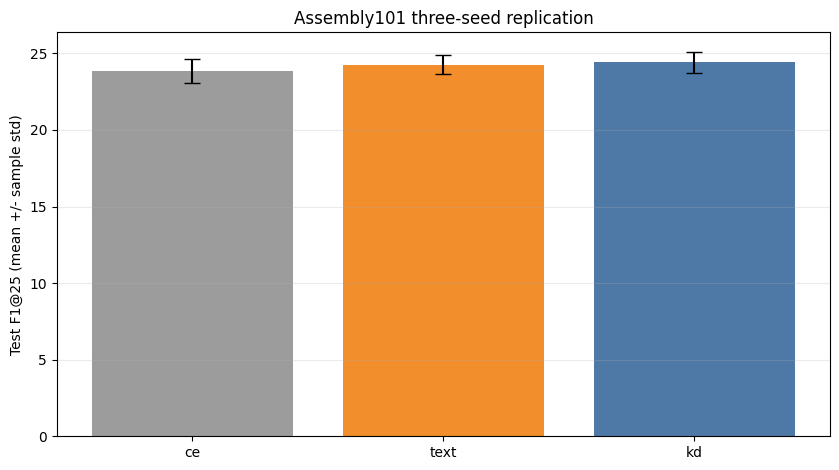

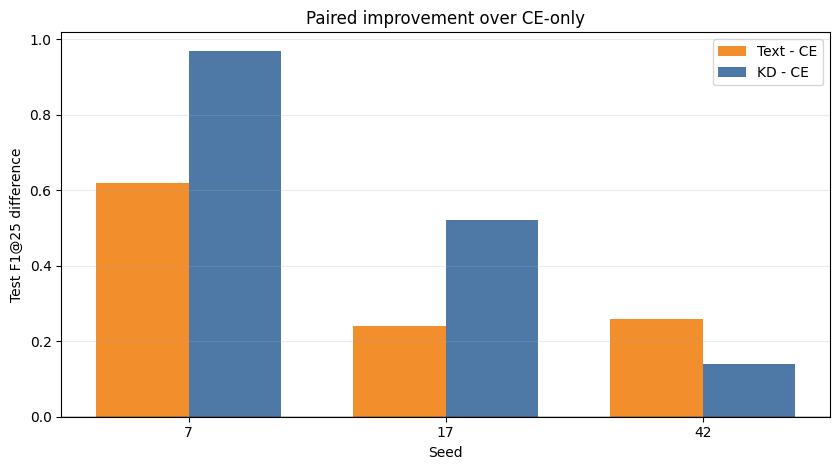

,strategy,mean_validation_score,std_validation_score,mean_validation_f1_25
0,kd,25.469983,0.774056,25.213333
1,text,25.276667,0.885131,25.016667
2,ce,24.913416,0.311247,24.656667


Recommended by mean validation score: kd
Test metrics used for recommendation: False


In [17]:
validation_ranking = (
    per_seed_df.groupby("strategy", as_index=False)
    .agg(
        mean_validation_score=("validation_score", "mean"),
        std_validation_score=("validation_score", "std"),
        mean_validation_f1_25=("val_f1@25", "mean"),
    )
    .sort_values(
        ["mean_validation_score", "mean_validation_f1_25"],
        ascending=False,
    )
    .reset_index(drop=True)
)
recommended_by_validation = str(validation_ranking.iloc[0]["strategy"])
validation_ranking_csv = ARTIFACT_ROOT / "validation_only_ranking.csv"
validation_ranking.to_csv(validation_ranking_csv, index=False)

colors = {"ce": "#9C9C9C", "text": "#F28E2B", "kd": "#4E79A7"}
plot_df = aggregate_df.set_index("strategy").loc[STRATEGIES].reset_index()
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.bar(
    plot_df["strategy"],
    plot_df["test_f1@25_mean"],
    yerr=plot_df["test_f1@25_std"],
    capsize=6,
    color=[colors[value] for value in plot_df["strategy"]],
)
ax.set_ylabel("Test F1@25 (mean +/- sample std)")
ax.set_title("Assembly101 three-seed replication")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
mean_std_plot = ARTIFACT_ROOT / "three_seed_test_f1_25_mean_std.png"
fig.savefig(mean_std_plot, dpi=180, bbox_inches="tight")
plt.show()

pivot_delta = paired_df.pivot(
    index="seed", columns="strategy", values="delta_f1@25"
).sort_index()
fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.arange(len(pivot_delta.index))
width = 0.36
ax.bar(x - width / 2, pivot_delta["text"], width, label="Text - CE", color=colors["text"])
ax.bar(x + width / 2, pivot_delta["kd"], width, label="KD - CE", color=colors["kd"])
ax.axhline(0.0, color="black", linewidth=1)
ax.set_xticks(x, [str(value) for value in pivot_delta.index])
ax.set_xlabel("Seed")
ax.set_ylabel("Test F1@25 difference")
ax.set_title("Paired improvement over CE-only")
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
paired_plot = ARTIFACT_ROOT / "paired_f1_25_deltas.png"
fig.savefig(paired_plot, dpi=180, bbox_inches="tight")
plt.show()

display(validation_ranking)
print("Recommended by mean validation score:", recommended_by_validation)
print("Test metrics used for recommendation:", False)


## 17. Final summary and robustness conclusion


In [18]:
def paired_conclusion(strategy):
    row = paired_summary_df.set_index("strategy").loc[strategy]
    mean_delta = float(row["delta_f1@25_mean"])
    wins = int(row["f1@25_wins_over_ce"])
    if mean_delta > 0 and wins >= 2:
        return (
            f"{strategy} has a positive mean paired F1@25 difference "
            f"({mean_delta:+.2f}) and beats CE on "
            f"{wins}/{len(ALL_SEEDS)} seeds."
        )
    if mean_delta > 0:
        return (
            f"{strategy} has a positive mean difference ({mean_delta:+.2f}) "
            f"but beats CE on only {wins}/{len(ALL_SEEDS)} seeds; "
            "the gain is unstable."
        )
    return (
        f"{strategy} does not retain a positive mean paired F1@25 "
        f"difference ({mean_delta:+.2f}); the single-seed gain is not reproduced."
    )


conclusions = [paired_conclusion("text"), paired_conclusion("kd")]
for conclusion in conclusions:
    print(conclusion)

final_summary = {
    "status": "completed",
    "run_mode": RUN_MODE,
    "experiment": "assembly101_three_seed_fixed_configuration_repetition",
    "seeds": ALL_SEEDS,
    "historical_seed": HISTORICAL_SEED,
    "newly_trained_seeds": REPLICATION_SEEDS,
    "strategies": {
        "ce": {"training_text": False},
        "text": {
            "training_text": True,
            "prototype_mode": FIXED_TEXT_MODE,
            "beta": FIXED_TEXT_BETA,
        },
        "kd": {
            "training_text": True,
            "lambda": FIXED_KD_LAMBDA,
            "temperature": FIXED_KD_TEMPERATURE,
            "stage_policy": FIXED_KD_STAGE_POLICY,
            "fixed_teacher_checkpoint": str(TEACHER_CHECKPOINT),
        },
    },
    "protocol": {
        "hyperparameters_reselected_per_seed": False,
        "checkpoint_selection": "validation F1@25 + 0.01 * validation Edit",
        "strategy_recommendation": "mean validation score across seeds",
        "test_used_for_selection": False,
        "teacher_retrained_per_seed": False,
        "paired_student_initialization": True,
    },
    "per_seed_results": per_seed_df.to_dict(orient="records"),
    "aggregate_results": aggregate_df.to_dict(orient="records"),
    "paired_deltas": paired_df.to_dict(orient="records"),
    "paired_delta_summary": paired_summary_df.to_dict(orient="records"),
    "validation_only_ranking": validation_ranking.to_dict(orient="records"),
    "recommended_by_validation": recommended_by_validation,
    "conclusions": conclusions,
    "limitations": [
        "Only three student seeds are evaluated.",
        "Seed 7 is also the seed used for the original hyperparameter selection.",
        "The privileged teacher is fixed, so teacher-training variance is not measured.",
        "The sequence representation has only 16 temporal positions.",
        "Mean and sample standard deviation are descriptive, not a significance test.",
    ],
    "inference_contract": {
        "call": "student(video)",
        "external_text_input": False,
        "ground_truth_text": False,
        "teacher_called": False,
        "text_auxiliary_head_called": False,
    },
    "environment": {
        "python": platform.python_version(),
        "torch": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "gpu": (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available() else None
        ),
    },
    "paths": {
        "output_root": str(ARTIFACT_ROOT),
        "per_seed_results": str(per_seed_csv),
        "aggregate_results": str(aggregate_csv),
        "paired_deltas": str(paired_csv),
        "paired_delta_summary": str(paired_summary_csv),
        "validation_only_ranking": str(validation_ranking_csv),
        "mean_std_plot": str(mean_std_plot),
        "paired_delta_plot": str(paired_plot),
    },
    "next_step": (
        "Update notebook 22, README, and presentation with the "
        "three-seed mean, sample standard deviation, and paired deltas."
    ),
    "created_utc": datetime.now(timezone.utc).isoformat(),
}

final_summary_path = ARTIFACT_ROOT / "final_summary.json"
final_summary_path.write_text(
    json.dumps(final_summary, indent=2), encoding="utf-8"
)

print("Saved:", per_seed_csv)
print("Saved:", aggregate_csv)
print("Saved:", paired_csv)
print("Saved:", paired_summary_csv)
print("Saved:", validation_ranking_csv)
print("Saved:", mean_std_plot)
print("Saved:", paired_plot)
print("Saved:", final_summary_path)


text has a positive mean paired F1@25 difference (+0.37) and beats CE on 3/3 seeds.
kd has a positive mean paired F1@25 difference (+0.54) and beats CE on 3/3 seeds.
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/23_three_seed_repetition/full/per_seed_results.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/23_three_seed_repetition/full/aggregate_results.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/23_three_seed_repetition/full/paired_deltas.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/23_three_seed_repetition/full/paired_delta_summary.csv
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streami